# Uncertainty breakdown + selected event distribution for $\delta p_T$

Plots the per-category systematic uncertainty breakdown (Flux, GENIE, G4, Detector, Cosmics, MC stat.,
Exposure, Targets) plus data statistical uncertainty for `tki-del_Tp`, with the MC selected-event
distribution shown on the background (secondary y-axis).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from os import path
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana')

from pyanalib.split_df_helpers import load_dfs
from pyanalib.split_df_helpers_new import dfs_from_dir
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import save_fig_base_dir
from analysis_village.numucc_1p0pi.dataset_locations import PLOTS_BASE
from analysis_village.numucc_1p0pi.syst_category_summary import (
    load_category_syst_summary,
    total_frac_unc_pct,
    total_cov_frac,
    category_frac_unc_pct,
    frac_unc_pct,
    frac_weights_for_plot,
    TOTAL_XSEC,
    POT_FRAC_UNC_PCT,
    NTARGETS_FRAC_UNC_PCT,
    CAT_FLUX,
    CAT_G4,
    CAT_MCSTAT,
    CAT_DETECTOR,
    CAT_COSMICS,
    CAT_GENIE_XSEC,
    CAT_GENIE_RATE,
    CAT_POT,
    CAT_NTARGETS,
)
from analysis_village.numucc_1p0pi.syst_disk_layout import category_summary_npz_path

plt.style.use("presentation.mplstyle")

## Configuration

In [3]:
var_config = VariableConfig.tki_del_Tp()
vsn = var_config.var_save_name

SYST_DISK_ROOT = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final"
CATEGORY_SUMMARY_NPZ = category_summary_npz_path(SYST_DISK_ROOT)

DFS_ROOT = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs"
QUALITY_DF_DIR = path.join(DFS_ROOT, "2026_05_16_230705__sel_mup-data-1e20/merged_perTPC")
QUALITY_DF_PATH = path.join(QUALITY_DF_DIR, "beam_data_1e20_qualitycut.df")
DIR_MC = path.join(DFS_ROOT, "2026_05_11_084007__sel_mup-wgts_mcstat/merged_perTPC")
DIR_INTIME = path.join(DFS_ROOT, "2026_05_11_083624__sel_mup-mc-Intime/merged_perTPC")
DIR_OFFBEAM = path.join(DFS_ROOT, "2026_05_11_040015__sel_mup-data-OffBeamLight/merged_perTPC")

SYST_KIND = "xsec"

print("Variable:", vsn)
print("SYST_DISK_ROOT:", SYST_DISK_ROOT)
print("Category summary NPZ:", CATEGORY_SUMMARY_NPZ, "exists =", path.isfile(CATEGORY_SUMMARY_NPZ))

Variable: tki-del_Tp
SYST_DISK_ROOT: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final
Category summary NPZ: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/CategorySummary/category_syst_summary.npz exists = True


## Load systematics summary

In [4]:
summary = load_category_syst_summary(CATEGORY_SUMMARY_NPZ)

# Per-category fractional uncertainty (%)
category_plot_config = [
    (CAT_FLUX,       "Flux"),
    (CAT_GENIE_XSEC, "GENIE"),
    (CAT_G4,         "G4"),
    (CAT_DETECTOR,   "Detector"),
    (CAT_COSMICS,    "Cosmics"),
    (CAT_MCSTAT,     "MC stat."),
]

category_pct = {}
pack = summary["by_var"][vsn]
for cat_key, cat_label in category_plot_config:
    if cat_key in pack["categories"]:
        category_pct[cat_label] = frac_weights_for_plot(
            pack["categories"][cat_key]["cov_frac"], var_config
        )

# Flat uncertainties
n_bins = len(var_config.bin_centers)
category_pct["Exposure"] = np.full(n_bins, POT_FRAC_UNC_PCT)
category_pct["Targets"] = np.full(n_bins, NTARGETS_FRAC_UNC_PCT)

# Total systematic (sum all categories in quadrature)
total_syst_cov_frac = total_cov_frac(summary, vsn, kind=SYST_KIND)
total_syst_pct = frac_weights_for_plot(total_syst_cov_frac, var_config)
total_syst_frac = total_syst_pct / 100.0
total_syst_frac = np.sqrt(
    total_syst_frac**2
    + (POT_FRAC_UNC_PCT / 100.0)**2
    + (NTARGETS_FRAC_UNC_PCT / 100.0)**2
)
total_syst_pct = 100.0 * total_syst_frac

print(f"Total syst uncertainty (% per bin): {total_syst_pct}")
for lab, w in category_pct.items():
    print(f"  {lab:12s}: max = {w.max():.1f}%")

Total syst uncertainty (% per bin): [ 9.62005934  7.97353936  8.09217079  8.16470869  8.66144041  9.73865269
 11.38301917 11.88997176 12.48100842 21.45879676 34.11924068 56.69589893]
  Flux        : max = 7.9%
  GENIE       : max = 52.0%
  G4          : max = 14.6%
  Detector    : max = 8.3%
  Cosmics     : max = 8.2%
  MC stat.    : max = 9.4%
  Exposure    : max = 2.0%
  Targets     : max = 1.0%


## Load data and MC

In [5]:
KEYS2LOAD = ["hdr", "evt"]
N_MAX_CONCAT = 999

mc_dfs = dfs_from_dir(
    DIR_MC,
    filename_str="sel_mup-wgts_mcstat",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)
mc_evt_df = mc_dfs["evt"]
mc_hdr_df = mc_dfs["hdr"]

intime_dfs = dfs_from_dir(
    DIR_INTIME,
    filename_str="sel_mup-mc-Intime",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)
intime_evt_df = intime_dfs["evt"]
intime_hdr_df = intime_dfs["hdr"]

offbeam_dfs = dfs_from_dir(
    DIR_OFFBEAM,
    filename_str="sel_mup-data-OffBeamLight",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)
offbeam_evt_df = offbeam_dfs["evt"]
offbeam_hdr_df = offbeam_dfs["hdr"]

quality_dfs = load_dfs(
    QUALITY_DF_PATH,
    keys2load=["hdr", "trigger", "evt_good"],
    n_max_concat=1,
)
data_evt_df = quality_dfs["evt_good"]
data_hdr_df = quality_dfs["hdr"].join(quality_dfs["trigger"])

print(f"mc: evt={len(mc_evt_df):,}  data: evt={len(data_evt_df):,}")

Found 2 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_084007__sel_mup-wgts_mcstat/merged_perTPC/2026_05_11_084007__sel_mup-wgts_mcstat_merged_0000.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_084007__sel_mup-wgts_mcstat/merged_perTPC/2026_05_11_084007__sel_mup-wgts_mcstat_merged_0001.df']


100%|██████████| 2/2 [00:09<00:00,  4.78s/it]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 1 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_083624__sel_mup-mc-Intime/merged_perTPC/2026_05_11_083624__sel_mup-mc-Intime_merged_0000.df']


100%|██████████| 1/1 [00:03<00:00,  3.04s/it]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 1 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_040015__sel_mup-data-OffBeamLight/merged_perTPC/2026_05_11_040015__sel_mup-data-OffBeamLight_merged_0000.df']


100%|██████████| 1/1 [00:03<00:00,  3.11s/it]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
mc: evt=54,287  data: evt=12,804


## Compute POT scaling

In [6]:
data_tot_pot = data_hdr_df["pot"].sum() * 0.98
data_gates = data_hdr_df.nbnbinfo.sum()

mc_tot_pot = mc_hdr_df["pot"].sum()
mc_pot_scale = data_tot_pot / mc_tot_pot

intime_gates = offbeam_hdr_df[offbeam_hdr_df["first_in_subrun"] == 1]["noffbeambnb"].sum()
f = 0.0753
scale_intime_to_lightdata = (1 - f) * data_gates / intime_gates

print(f"mc_pot_scale: {mc_pot_scale:.3e}")
print(f"intime data scale: {scale_intime_to_lightdata:.2f}")

mc_pot_scale: 2.125e-01
intime data scale: 0.22


## Per-TPC containment cut

In [7]:
perTPC_inset = 10

def perTPC_cut(df):
    in_TPC1 = (
        InFV(df.slc.vertex, det="SBND_TPC1", incathode=perTPC_inset)
        & InFV(df.mu.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
        & InFV(df.p.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
    )
    in_TPC2 = (
        InFV(df.slc.vertex, det="SBND_TPC2", incathode=perTPC_inset)
        & InFV(df.mu.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
        & InFV(df.p.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
    )
    return in_TPC1 | in_TPC2

mc_evt_df = mc_evt_df[perTPC_cut(mc_evt_df)]
intime_evt_df = intime_evt_df[perTPC_cut(intime_evt_df)]

print(f"perTPC: data={len(data_evt_df):,} mc={len(mc_evt_df):,} intime={len(intime_evt_df):,}")

perTPC: data=12,804 mc=54,287 intime=96


## Compute data stat uncertainty and build histograms

In [8]:
bins = var_config.bins
bc = var_config.bin_centers
col = var_config.var_evt_reco_col

# Data histogram
n_data, _ = np.histogram(data_evt_df[col], bins=bins)
n_data = np.asarray(n_data, dtype=np.float64)

# Data statistical uncertainty (%)
with np.errstate(divide="ignore", invalid="ignore"):
    data_stat_pct = np.where(n_data > 0, 100.0 / np.sqrt(n_data), 0.0)

# MC histogram (POT-scaled)
n_mc, _ = np.histogram(mc_evt_df[col], bins=bins)
n_mc_scaled = np.asarray(n_mc, dtype=np.float64) * mc_pot_scale

# Intime cosmics (scaled)
n_intime, _ = np.histogram(intime_evt_df[col], bins=bins)
n_intime_scaled = np.asarray(n_intime, dtype=np.float64) * scale_intime_to_lightdata

# Total MC prediction
n_mc_total = n_mc_scaled + n_intime_scaled

print(f"Data events: {n_data.sum():.0f}")
print(f"MC (scaled): {n_mc_total.sum():.1f}")

Data events: 12801
MC (scaled): 11554.0


## Plot: total uncertainty + selected event distribution

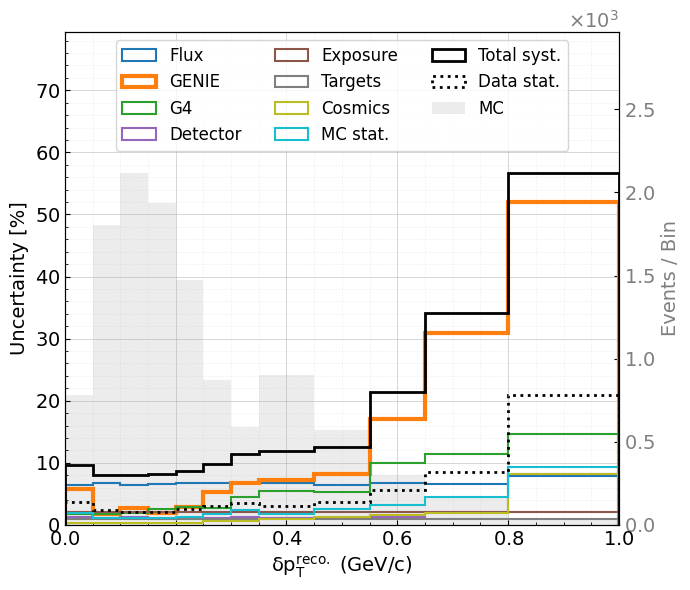

In [17]:
fig, ax1 = plt.subplots(figsize=(7, 6))

# --- Secondary axis (background): MC event distribution ---
ax2 = ax1.twinx()

ax2.hist(
    bc, bins=bins, weights=n_mc_total,
    histtype="stepfilled", alpha=0.15, color="gray", label="MC",
)
ax2.set_ylabel("Events / Bin", color="tab:gray")
ax2.tick_params(axis="y", labelcolor="tab:gray")
ax2.set_ylim(0, np.max(n_mc_total) * 1.4)

# --- Primary axis (foreground): per-category uncertainty breakdown ---
CATEGORY_PLOT_ORDER = ["Flux", "GENIE", "G4", "Detector", "Exposure", "Targets", "Cosmics", "MC stat."]
colors = plt.cm.tab10(np.linspace(0, 1, len(CATEGORY_PLOT_ORDER)))

for i, lab in enumerate(CATEGORY_PLOT_ORDER):
    if lab == "GENIE":
        linewidth = 3
    else:
        linewidth = 1.5
    if lab not in category_pct:
        continue
    ax1.hist(
        bc, bins=bins, weights=category_pct[lab],
        histtype="step", linewidth=linewidth, color=colors[i], label=lab,
    )

# Total systematic
ax1.hist(
    bc, bins=bins, weights=total_syst_pct,
    histtype="step", linewidth=2., color="k", label="Total syst.",
)

# Data statistical uncertainty
ax1.hist(
    bc, bins=bins, weights=data_stat_pct,
    histtype="step", linewidth=2., color="k", linestyle=":", label="Data stat.",
)

ax1.set_xlabel(var_config.var_labels[1])
ax1.set_ylabel("Uncertainty [%]")
ax1.set_xlim(bins[0], bins[-1])
ax1.set_ylim(0, max(total_syst_pct.max(), data_stat_pct.max()) * 1.4)
ax1.grid(which="major", linestyle="-", linewidth=0.6, alpha=0.6)
ax1.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.4)
ax1.minorticks_on()

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center", ncol=3, fontsize=12)

ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

fig.tight_layout()
plt.show()